# Mini-GPT

> 一台完整的 GPT 模型，数据流要经过三段：输入端的 Embedding 把 token ID 变成向量，中间的 Transformer Block 让向量之间交换信息，输出端的投影层把向量变回对词表的预测。上一节实现的 Transformer Block 位于数据流的中间——它接收 `[batch, seq, d_model]` 的向量，做 Attention 和 FFN，输出同样形状的向量。
>
> 但 Block 的两端还是断的。它不能直接接收整数 token ID，也不能输出词表大小的 logits。这一节把输入和输出接上去，跑通完整的数据流。

Embedding 是一张 `[vocab_size, d_model]` 的矩阵，查表即可把整数变成向量。Self-Attention 只看向量之间的关系，不知道谁先谁后，所以 Embedding 之后还要加上位置编码。Block 处理完之后，用一个线性层投影到 `vocab_size` 维，得到 logits。

假设词表 30 个 token，d_model=64。输入三个 token ID `[5, 12, 3]`，经过 Embedding 和位置编码变成 `[3, 64]`，穿过 N 层 Block 后形状不变，最后投影为 `[3, 30]`——每个位置输出 30 个分数，表示模型对下一个 token 的预测倾向。

下面先看清 GPT 的整体结构，再逐步实现各个组件。

语言模型的核心任务是预测下一个 token。给定「今天天气」四个字，模型要判断下一个位置出现「很」的概率高于「苹果」。这个过程是单向的——从左到右，只看已经出现过的内容。

原始 Transformer 是为机器翻译设计的 Encoder-Decoder 结构：Encoder 先读完源语言句子，Decoder 再通过 Cross-Attention 读取 Encoder 的结果，逐词生成目标语言。语言模型不需要这种双段式设计——给定前文，直接预测下一个 token 即可。GPT 系列因此只保留 Decoder 主干，去掉了 Encoder 和 Cross-Attention。这种结构称为 Decoder-Only。

```text
GPT / Decoder-Only

Token IDs
  ↓
Token Embedding + Position Embedding
  ↓
Masked Self-Attention   ← 只能看当前位置及之前的 token
  ↓
Feed-Forward Network
  ↓
重复很多层 Decoder Block
  ↓
LM Head
  ↓
预测下一个 token
```

作为对比，原始 Transformer 是 Encoder-Decoder 结构，常用于翻译这类「先读输入，再生成输出」的任务：

```text
原始 Transformer / Encoder-Decoder

输入句子 → Encoder → Encoder 输出
                         ↓
目标前缀 → Decoder → Cross-Attention 读取 Encoder 输出
                         ↓
                      生成下一个 token
```

将两张图对比来看：原始 Transformer 的 Decoder 有两类 Attention——Masked Self-Attention（看自己的前缀）和 Cross-Attention（看 Encoder 的输出）。GPT 系列只有 Masked Self-Attention，因为是纯生成模型，没有 Encoder。

## 从零实现 MiniGPT

接下来从零实现 MiniGPT，用小规模配置（vocab_size=30, d_model=64）逐步搭建。先以 `batch_size=2, seq_len=3` 为例，看清张量形状一路怎么变：

```text
输入（整数 token ID）
  [[5, 12, 3],          ← 样本 0
   [2, 7,  1]]          ← 样本 1
  shape: [2, 3]
        ↓ Token Embedding       每个 ID 查到 64 维向量
        ↓ + Position Encoding   同形状叠加
  shape: [2, 3, 64]
        ↓ N 层 TransformerBlock 形状保持不变
  shape: [2, 3, 64]
        ↓ LayerNorm + lm_head   投影到词表大小
  shape: [2, 3, 30]
  每个位置输出 30 个分数，对应词表里 30 个 token 的预测
```

整条数据流只有两处形状转折：输入端把整数 ID 展开成 d_model 维向量，输出端再把 d_model 维向量投影到 vocab_size；中间 N 层 Block 始终保持 `[batch, seq, d_model]` 不变——这个"形状不变"是它能堆叠 N 层的前提。

In [1]:
import torch.nn as nn
import torch.nn.functional as F
import math


class MultiHeadAttention(nn.Module):
    """
    多头自注意力；传入 causal mask 时就是因果自注意力。

    参数:
        d_model: 输入/输出维度
        num_heads: 注意力头数
    """
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model 必须能被 num_heads 整除"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # 每个头的维度

        # Q、K、V 的线性变换（把 num_heads 个头合并到矩阵操作里）
        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)

        # 输出投影
        self.W_O = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        """
        输入: x shape = [batch, seq_len, d_model]
        输出:   shape = [batch, seq_len, d_model]
        """
        batch_size, seq_len, _ = x.shape

        # 1. 线性变换 + 拆成多头
        #    [batch, seq_len, d_model] → [batch, num_heads, seq_len, d_k]
        Q = self.W_Q(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_K(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_V(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)

        # 2. 注意力分数: Q @ K^T
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)

        # 3. Mask（例如把未来的位置设为 -inf）
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))

        # 4. Softmax
        weights = F.softmax(scores, dim=-1)

        # 5. 加权求和
        attn_output = weights @ V  # [batch, num_heads, seq_len, d_k]

        # 6. 拼回头并投影
        attn_output = attn_output.transpose(1, 2).contiguous()
        attn_output = attn_output.view(batch_size, seq_len, self.d_model)
        return self.W_O(attn_output)


class FeedForward(nn.Module):
    """FFN：两层全连接，中间隐藏维度 4×d_model"""
    def __init__(self, d_model, d_ff=None):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))


class TransformerBlock(nn.Module):
    """一个 Transformer 解码器层：Attention + FFN，各带残差 + LayerNorm"""
    def __init__(self, d_model, num_heads, d_ff=None):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        x = self.norm1(x + self.attention(x, mask))  # x + Attention 输出，再过 LayerNorm
        x = self.norm2(x + self.ffn(x))              # x + FFN 输出，再过 LayerNorm
        return x

### MiniGPT 的实现

完整的 GPT 数据流由四个步骤组成：

**第一步：Token Embedding。** 输入序列是一组整数 token ID，比如 `[5, 12, 3]`。整数本身没有语义信息，需要通过一张 `[vocab_size, d_model]` 的查表矩阵，把每个 ID 映射成 d_model 维的向量。

**第二步：Position Encoding。** 同一个 token 出现在第 1 个位置和第 10 个位置，含义可能不同。Self-Attention 只看 token 之间的关系，没有位置信息，所以要在 Embedding 之后加上位置编码，让模型知道每个向量来自序列的第几个位置。

**第三步：多层 Transformer Block。** Embedding 加上位置编码之后的数据，依次经过 N 个 Transformer Block。每个 Block 做同一件事：让位置之间互相交换信息，再做非线性加工。多层堆叠让信息逐层融合——浅层捕捉相邻 token 的关系，深层捕捉更远、更抽象的依赖。

**最后一步：输出投影。** 经过 N 层 Block 之后，每个位置得到一个 d_model 维的向量。最后用一个线性层把它投影到词表大小 vocab_size，得到 logits——每个位置对词表中每个 token 的打分。

In [2]:
# 复用上一节的正弦位置编码
import torch
import torch.nn as nn
import math
def get_sinusoidal_encoding(seq_len, d_model):
    position = torch.arange(seq_len).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
    pe = torch.zeros(seq_len, d_model)
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe

class MiniGPT(nn.Module):
    """Mini GPT: Token Embedding → N 层 TransformerBlock → LayerNorm → 投影到词表

    组装关系（对应前面几节的内容）:
        token_emb  — Token Embedding，把整数 ID 查表变成向量（notebook 03）
        pe         — 正弦位置编码，告诉模型"这个向量来自第几个位置"（notebook 04）
        blocks     — N 层 TransformerBlock，每层做 Attention + FFN + 残差 + LayerNorm（notebook 05）
        ln_final   — 最终的 LayerNorm
        lm_head    — 线性层，把 d_model 维向量投影到词表大小，得到 logits

    参数:
        vocab_size:   词表大小（token 种类数）
        d_model:      每个向量的维度，也叫 hidden size
        num_heads:    多头注意力的头数
        num_layers:   Transformer Block 的层数
        max_seq_len:  最大序列长度（位置编码表的大小）
    """
    def __init__(self, vocab_size, d_model=64, num_heads=4, num_layers=4, max_seq_len=128):
        super().__init__()
        self.d_model = d_model

        # 输入端：Token Embedding + Position Encoding
        self.token_emb = nn.Embedding(vocab_size, d_model)
        pe = get_sinusoidal_encoding(max_seq_len, d_model)
        self.register_buffer('pe', pe)  # buffer 不参与梯度更新，但会随模型保存/加载

        # 中间：N 层 TransformerBlock
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads) for _ in range(num_layers)
        ])

        # 输出端：LayerNorm + 线性投影
        self.ln_final = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)  # d_model → vocab_size

    def forward(self, x):
        # x: [batch, seq_len] — 整数 token ID，如 [[5, 12, 3, 8], [2, 7, 1, 9]]
        batch_size, seq_len = x.shape

        # 1. Embedding：把整数 ID 变成 d_model 维向量，再加上位置编码
        #    shape: [batch, seq_len] → [batch, seq_len, d_model]
        x = self.token_emb(x) + self.pe[:seq_len, :]

        # 2. Causal mask：下三角全 1 矩阵
        #    mask[i, j] = 1 表示位置 i 可以看到位置 j
        #    因为是下三角，位置 i 只能看到 j <= i（自己及之前的 token）
        #    shape: [seq_len, seq_len] → [1, 1, seq_len, seq_len]（广播到 batch 和 heads）
        mask = torch.tril(torch.ones(seq_len, seq_len, device=x.device))
        mask = mask.view(1, 1, seq_len, seq_len)

        # 3. 依次经过 N 层 TransformerBlock，形状保持 [batch, seq_len, d_model] 不变
        for block in self.blocks:
            x = block(x, mask)

        # 4. 最终 LayerNorm + 投影到词表大小
        #    shape: [batch, seq_len, d_model] → [batch, seq_len, vocab_size]
        x = self.ln_final(x)
        return self.lm_head(x)

In [3]:
# 测试 MiniGPT：模型未训练，logits 是随机的，只看 shape 对不对
import torch
vocab_size = 30
model = MiniGPT(vocab_size=vocab_size, d_model=64, num_heads=4, num_layers=2)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"总参数量: {total_params:,}, 可训练: {trainable_params:,}")

# 前向传播: batch=2, seq_len=8
batch_input = torch.randint(0, vocab_size, (2, 8))
logits = model(batch_input)
print(f"\n输入: {batch_input.shape}  →  输出: {logits.shape}")
print(f"输出 = [batch=2, seq=8, vocab={vocab_size}] → 每个位置对每个词的 logits")
print(f"logits[0, 7, :5]: {logits[0, 7, :5].tolist()}  ← 样本 0 位置 7 预测下一 token 的分数")

总参数量: 103,966, 可训练: 103,966

输入: torch.Size([2, 8])  →  输出: torch.Size([2, 8, 30])
输出 = [batch=2, seq=8, vocab=30] → 每个位置对每个词的 logits
logits[0, 7, :5]: [0.17583158612251282, -0.26609236001968384, 0.08940065652132034, -0.22214078903198242, 0.5046164393424988]  ← 样本 0 位置 7 预测下一 token 的分数


In [4]:
# 跟着结构图跑一次：每一步都打印 shape
import torch
vocab_size = 30
model = MiniGPT(vocab_size=vocab_size, d_model=32, num_heads=4, num_layers=2, max_seq_len=16)
idx = torch.randint(0, vocab_size, (2, 6))  # batch=2, seq_len=6

with torch.no_grad():
    # 第一步：Token Embedding 查表
    token_vec = model.token_emb(idx)     # [2, 6] → [2, 6, 32]
    # 位置编码表取前 seq_len 行
    pos_vec = model.pe[:idx.shape[1], :]  # [6, 32]
    # 相加得到带位置信息的向量
    x = token_vec + pos_vec               # [2, 6, 32]
    print(f"1. token + position: {x.shape}")

    # 第二步：构造 causal mask（下三角矩阵，1=可见，0=遮住）
    mask = torch.tril(torch.ones(idx.shape[1], idx.shape[1]))  # [6, 6]
    mask = mask.view(1, 1, idx.shape[1], idx.shape[1])         # [1, 1, 6, 6]

    # 第三步：经过每层 TransformerBlock（Attention + FFN + 残差 + LN）
    for block_id, block in enumerate(model.blocks, start=1):
        x = block(x, mask)  # [2, 6, 32] → [2, 6, 32]，形状不变
        print(f"2.{block_id} 经过 TransformerBlock: {x.shape}")

    # 第四步：LayerNorm + 投影到词表
    x = model.ln_final(x)                # [2, 6, 32]
    logits = model.lm_head(x)            # [2, 6, 32] → [2, 6, 30]
    print(f"3. logits: {logits.shape}")

print("关键观察：中间一直是 d_model 维，只有最后一步才变成 vocab_size。")

1. token + position: torch.Size([2, 6, 32])
2.1 经过 TransformerBlock: torch.Size([2, 6, 32])
2.2 经过 TransformerBlock: torch.Size([2, 6, 32])
3. logits: torch.Size([2, 6, 30])
关键观察：中间一直是 d_model 维，只有最后一步才变成 vocab_size。


### Logits 和预测

上一节的代码输出了一个叫 logits 的张量，形状是 `[batch, seq, vocab_size]`。这一节解释它是什么。

logits 是模型最后输出的原始分数。如果词表有 30 个 token，那么每个位置都会输出 30 个分数：

```text
logits[batch, 位置, token_id]
```

分数越高，模型越认为这个 token 适合作为"下一个 token"。举个例子，如果 `logits[0, 7, 12] = 2.3` 是位置 7 上最大的分数，说明模型（在当前参数下）倾向于在位置 7 之后输出 ID 为 12 的 token。

训练时，会用 Cross-Entropy Loss 让正确答案的分数变高、错误答案的分数变低。生成时，会对 logits 做 softmax 得到概率分布，再从中抽样或取最大值。这些内容在后续章节展开。

### Special Tokens

MiniGPT 能输出 logits 了，但在实际使用中，模型还需要一些"边界符号"来标记序列的结构。

比如：序列从哪里开始、到哪里结束、哪些位置只是用来补齐长度的。在一些场景中，模型还需要区分"思考过程"和"最终回答"。这些特殊标记统称为 special tokens：

```text
<BOS>       begin of sequence，标记序列的开始
<EOS>       end of sequence，标记序列的结束，生成时遇到它就停止
<PAD>       padding，用来补齐长度，标记这个位置不是真实内容
<think>     thinking start，标记下面进入思考区间
</think>    thinking end，标记思考区间结束，下面给最终回答
```

需要注意的是，`<think>` 不会让模型自动变聪明。它只是一个符号——模型要学会正确使用它，训练数据里必须反复出现这种格式。

In [5]:
# 演示：给 Mini-GPT 的词表加入新的 special tokens
base_vocab = {
    "用户": 0,
    "助手": 1,
    "答案": 2,
    "357": 3,
    "289": 4,
    "103173": 5,
}

special_tokens = ["<BOS>", "<EOS>", "<PAD>", "<think>", "</think>"]

vocab = base_vocab.copy()
for token in special_tokens:
    if token not in vocab:
        vocab[token] = len(vocab)

print("新增后的 special token ID:")
for token in special_tokens:
    print(f"  {token:8s} -> {vocab[token]}")

print()
print("关键观察：<think> 和 </think> 现在有独立 ID，")
print("模型才能把它们当成边界符号，而不是普通文字碎片。")

新增后的 special token ID:
  <BOS>    -> 6
  <EOS>    -> 7
  <PAD>    -> 8
  <think>  -> 9
  </think> -> 10

关键观察：<think> 和 </think> 现在有独立 ID，
模型才能把它们当成边界符号，而不是普通文字碎片。


In [6]:
# 演示：一条带 <think> 的训练样本长什么样
sample_tokens = [
    "<BOS>",
    "用户",
    "357",
    "289",
    "助手",
    "<think>",
    "357",
    "289",
    "103173",
    "</think>",
    "答案",
    "103173",
    "<EOS>",
]

sample_ids = [vocab[token] for token in sample_tokens]

print("训练样本 token:")
print(sample_tokens)
print()
print("训练样本 ID:")
print(sample_ids)
print()
print("关键观察：训练数据里出现这种格式，模型才会学会什么时候开始想、什么时候结束想。")

训练样本 token:
['<BOS>', '用户', '357', '289', '助手', '<think>', '357', '289', '103173', '</think>', '答案', '103173', '<EOS>']

训练样本 ID:
[6, 0, 3, 4, 1, 9, 3, 4, 5, 10, 2, 5, 7]

关键观察：训练数据里出现这种格式，模型才会学会什么时候开始想、什么时候结束想。


新增 special tokens 后，词表变大了。词表一变大，Embedding 表也要跟着扩容，因为每个 token 都要有自己的向量。

In [7]:
# 用小矩阵演示：新增 token 后，Embedding 为什么要扩容
import torch
import torch.nn as nn
old_vocab_size = len(base_vocab)
new_vocab_size = len(vocab)
d_model = 8

torch.manual_seed(42)
old_embedding = nn.Embedding(old_vocab_size, d_model)
new_embedding = nn.Embedding(new_vocab_size, d_model)

# 旧 token 的向量复制过去，新 token 的向量保留随机初始化，后续训练会更新它们
with torch.no_grad():
    new_embedding.weight[:old_vocab_size] = old_embedding.weight

print(f"旧词表大小: {old_vocab_size}")
print(f"新词表大小: {new_vocab_size}")
print(f"Embedding 形状: {tuple(new_embedding.weight.shape)}")
print()
print("关键观察：新增 5 个 special tokens 后，Embedding 也多了 5 行。")
print("这些新行要靠后续训练，才会学到 <think>、</think> 的真正用途。")


旧词表大小: 6
新词表大小: 11
Embedding 形状: (11, 8)

关键观察：新增 5 个 special tokens 后，Embedding 也多了 5 行。
这些新行要靠后续训练，才会学到 <think>、</think> 的真正用途。


## nanoGPT：从教学版到工程实现

到这里我们已经把 GPT 的每一个零件——Embedding、Attention、FFN、Transformer Block——都从零实现了一遍。串起来就是 MiniGPT：词表 30、隐藏维度 64、参数量约 10 万。这个规模刚好能跑、能验证数据流，作为教学装置足够了。

但教学装置和真实模型之间还隔着数量级的差距。真实的 GPT-2 Small，词表 50257，隐藏维度 768，12 层 Block，参数量约 1.24 亿——是 MiniGPT 的一千多倍。这个尺度上，光组装零件是不够的：参数怎么初始化才稳定、Attention 怎么实现才不爆显存、optimizer 怎么分组、输入输出 embedding 要不要共享权重，这些都是工程实现绕不开的问题。

Karpathy（OpenAI 创始成员之一、前特斯拉 AI 总监，写了一系列从零开始的神经网络教程）开源的 [nanoGPT](https://github.com/karpathy/nanoGPT) 就是 GPT-2 Small 的完整工程实现：同样的零件，同样的数据流，只是配置和工程细节按真实训练脚本的标准来。代码只有 300 多行，没有花哨的抽象，可以一行一行读。

接下来我们一起来看 nanoGPT 的实现。

### 从 MiniGPT 到 nanoGPT

读 nanoGPT 代码时第一道坎是命名——它用的标识符和前面手写的 MiniGPT 不一样，但做的事情一一对应。先把这张对照表放在前面，后面读代码时随时回来查：

| 教学版 | nanoGPT | 作用 |
|:---|:---|:---|
| `MiniGPT` | `GPT` | decoder-only 语言模型 |
| `TransformerBlock` | `Block` | 一层 Transformer Block（Attention + MLP + 残差 + LayerNorm） |
| `MultiHeadAttention` | `CausalSelfAttention` | 因果多头自注意力 |
| `FeedForward` | `MLP` | 两层全连接前馈网络 |
| `token_emb` | `transformer.wte` | token embedding 查表 |
| `pe / position` | `transformer.wpe` | 位置 embedding 查表 |
| `lm_head` | `lm_head` | hidden state 投影到词表 |

结构层面 nanoGPT 没有新东西，只是把同样的部件按工业标准重新组装：参数初始化更精细、Attention 用 Flash Attention 加速、weight tying 共享输入输出 embedding、optimizer 做了参数分组。下面先让它跑起来。

### 跑通 nanoGPT

不要急着读源码——先让 nanoGPT 实际跑一次 forward，看它输出的 shape 对不对、初始 loss 接不接近随机水平。跑通之后再做几个小实验，观察模型结构怎么影响参数量和运行时间。这些具体观察会成为后面读源码时的抓手。

**先跑一次 forward**

In [8]:
# 运行 nanoGPT 的 tiny 配置
from karpathy_models import NanoGPT, NanoGPTConfig

import torch
nano_config = NanoGPTConfig(
    block_size=16,
    vocab_size=64,
    n_layer=2,
    n_head=2,
    n_embd=32,
    dropout=0.0,
    bias=True,
)

torch.manual_seed(42)
nano_model = NanoGPT(nano_config)
nano_model.eval()

idx = torch.randint(0, nano_config.vocab_size, (2, 8))
targets = torch.randint(0, nano_config.vocab_size, (2, 8))

with torch.no_grad():
    nano_logits, nano_loss = nano_model(idx, targets)

print("=== nanoGPT tiny forward ===")
print(f"input shape:  {tuple(idx.shape)}")
print(f"logits shape: {tuple(nano_logits.shape)}")
print(f"loss:         {nano_loss.item():.4f}")
print(f"params:       {nano_model.get_num_params():,}")
print("观察：logits 仍然是 [batch, seq, vocab_size]。")


number of parameters: 0.03M
=== nanoGPT tiny forward ===
input shape:  (2, 8)
logits shape: (2, 8, 64)
loss:         4.1788
params:       27,520
观察：logits 仍然是 [batch, seq, vocab_size]。


**拆解每个组件的参数量**

总参数量是一个数字，看不出参数都花在哪些组件上。用 PyTorch 自带的 `named_children()` 列出 nanoGPT 的顶层子模块，统计各自的参数量。nanoGPT 把大部分组件装在一个叫 `transformer` 的容器里，所以再下钻一层看它的内部。

nanoGPT 用了 weight tying——`lm_head` 和 `transformer.wte` 共享同一份权重。下面的统计把这份权重只算一次，所以 `lm_head` 单独看时显示为 0；weight tying 的具体含义放在后面专门讲。

In [9]:
# 拆解 nanoGPT 的顶层组件 + transformer 内部的参数量
def count_params(module, seen=None):
    """统计模块参数量；传入 seen 时跳过已见参数（用于处理 weight tying）"""
    if seen is None:
        seen = set()
    total = 0
    for p in module.parameters():
        if id(p) in seen:
            continue
        seen.add(id(p))
        total += p.numel()
    return total

# 顶层视角：按 named_children 顺序累加，tied 权重只算一次
print("=== nanoGPT 顶层组件（tied 权重只算一次） ===")
seen = set()
for name, module in nano_model.named_children():
    print(f"{name:12s}  params={count_params(module, seen):,}")

# transformer 内部视角：列出这个容器里各子模块的参数量
print()
print("=== transformer 内部 ===")
for name, module in nano_model.transformer.named_children():
    print(f"{name:12s}  params={count_params(module):,}")

print()
print("观察：参数大头在 transformer.h（多层 Block）。")
print("顶层视角下 lm_head 因为和 wte 共享权重（weight tying），显示为 0。")

=== nanoGPT 顶层组件（tied 权重只算一次） ===
transformer   params=28,032
lm_head       params=0

=== transformer 内部 ===
wte           params=2,048
wpe           params=512
drop          params=0
h             params=25,408
ln_f          params=64

观察：参数大头在 transformer.h（多层 Block）。
顶层视角下 lm_head 因为和 wte 共享权重（weight tying），显示为 0。


**几个结构和行为实验**

上一节只跑了 forward 验证 shape 对。再做几个小实验，观察 nanoGPT 的结构怎么影响参数量、运行时间和初始 loss：

1. 模型变深（层数增加），参数量怎么变化？
2. 序列变长，forward 时间怎么变化？
3. 随机初始化模型的 loss 和随机猜测水平是否接近？

这些实验跑的都是**还没训练**的模型——目的是观察结构本身的性质，不是看生成效果。生成效果要等预训练完再看。

number of parameters: 0.01M
number of parameters: 0.03M
number of parameters: 0.05M
number of parameters: 0.08M
n_layer=1: params=14,816
n_layer=2: params=27,520
n_layer=4: params=52,928
n_layer=6: params=78,336
观察：层数越多，Block 里的 Attention 和 MLP 参数会近似线性增加。


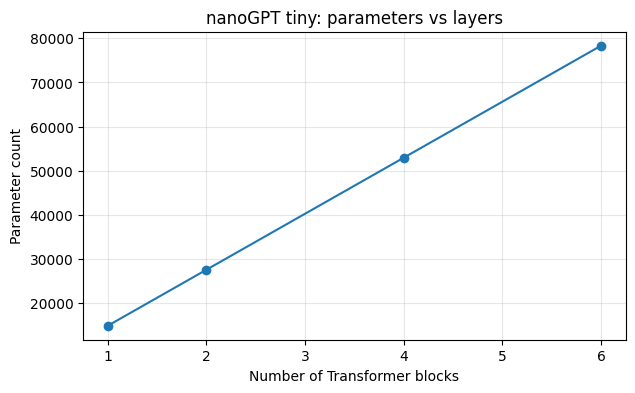

In [10]:
import matplotlib.pyplot as plt
# 实验 1：层数增加时，nanoGPT 参数量怎么变
layer_counts = [1, 2, 4, 6]
nano_param_counts = []

for n_layer in layer_counts:
    cfg = NanoGPTConfig(
        block_size=16,
        vocab_size=64,
        n_layer=n_layer,
        n_head=2,
        n_embd=32,
        dropout=0.0,
        bias=True,
    )
    model = NanoGPT(cfg)
    nano_param_counts.append(model.get_num_params())

plt.figure(figsize=(7, 4))
plt.plot(layer_counts, nano_param_counts, marker="o")
plt.xlabel("Number of Transformer blocks")
plt.ylabel("Parameter count")
plt.title("nanoGPT tiny: parameters vs layers")
plt.grid(True, alpha=0.3)
plt.show()

for n_layer, params in zip(layer_counts, nano_param_counts):
    print(f"n_layer={n_layer}: params={params:,}")

print("观察：层数越多，Block 里的 Attention 和 MLP 参数会近似线性增加。")


seq_len= 4: avg_forward_time=0.110340s
seq_len= 8: avg_forward_time=0.111186s
seq_len=12: avg_forward_time=0.113103s
seq_len=16: avg_forward_time=0.118013s
观察：Self-Attention 要看 token 两两关系，序列变长时计算通常会更贵。


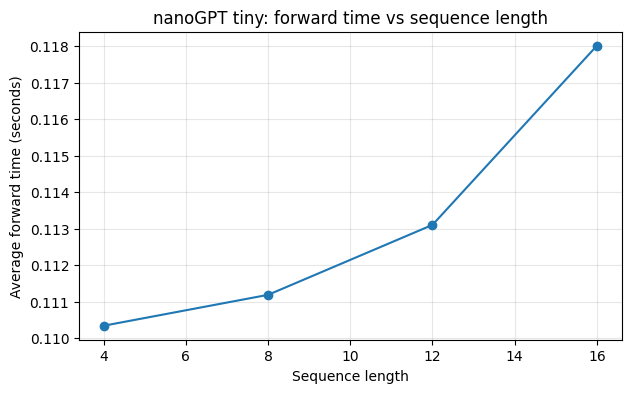

In [11]:
import matplotlib.pyplot as plt
import time
# 实验 2：序列长度增加时，forward 时间怎么变
# 注意：CPU 上单次运行波动很大，所以每个长度跑多次取平均。
import torch
def benchmark_forward(model, seq_len, repeats=20):
    sample = torch.randint(0, nano_config.vocab_size, (2, seq_len))
    target = torch.randint(0, nano_config.vocab_size, (2, seq_len))
    with torch.no_grad():
        model(sample, target)  # warmup
    start = time.perf_counter()
    with torch.no_grad():
        for _ in range(repeats):
            model(sample, target)
    elapsed = time.perf_counter() - start
    return elapsed / repeats

seq_lengths = [4, 8, 12, 16]
forward_times = []
for seq_len_value in seq_lengths:
    forward_times.append(benchmark_forward(nano_model, seq_len_value))

plt.figure(figsize=(7, 4))
plt.plot(seq_lengths, forward_times, marker="o")
plt.xlabel("Sequence length")
plt.ylabel("Average forward time (seconds)")
plt.title("nanoGPT tiny: forward time vs sequence length")
plt.grid(True, alpha=0.3)
plt.show()

for seq_len_value, seconds in zip(seq_lengths, forward_times):
    print(f"seq_len={seq_len_value:2d}: avg_forward_time={seconds:.6f}s")

print("观察：Self-Attention 要看 token 两两关系，序列变长时计算通常会更贵。")


nanoGPT loss:       4.1190
random guess loss:  4.1589
观察：没训练的 GPT，loss 接近随机猜测水平。这是正常的。


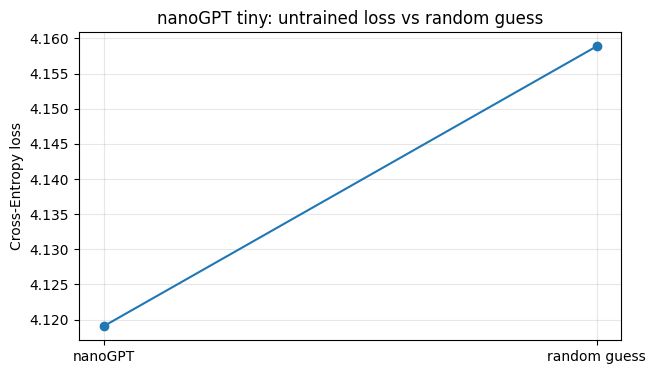

In [12]:
import matplotlib.pyplot as plt
# 实验 3：nanoGPT 随机初始化 loss 与随机猜测水平
# 模型还没训练，所以 loss 应该接近 log(vocab_size)。
import torch
import math
torch.manual_seed(123)
compare_idx = torch.randint(0, 64, (4, 12))
compare_targets = torch.randint(0, 64, (4, 12))

with torch.no_grad():
    compare_logits, compare_loss = nano_model(compare_idx, compare_targets)

random_guess_loss = math.log(64)
losses = [compare_loss.item(), random_guess_loss]
names = ["nanoGPT", "random guess"]

plt.figure(figsize=(7, 4))
plt.plot(names, losses, marker="o")
plt.ylabel("Cross-Entropy loss")
plt.title("nanoGPT tiny: untrained loss vs random guess")
plt.grid(True, alpha=0.3)
plt.show()

print(f"nanoGPT loss:       {compare_loss.item():.4f}")
print(f"random guess loss:  {random_guess_loss:.4f}")
print("观察：没训练的 GPT，loss 接近随机猜测水平。这是正常的。")


### 读懂 nanoGPT 源码

跑通之后回头读源码。nanoGPT 的 `model.py` 只有 300 多行，建议从外到内读：先看顶层 `GPT` 类的整体结构，再追 `GPT.forward` 的数据流，最后看几个工程细节——参数都花在哪、为什么 Weight Tying 让输入输出 embedding 共享权重。这些都是真实 GPT-2 训练脚本里能看到的选择。

**model.py 的阅读顺序**

**model.py 的阅读顺序**

读 nanoGPT 的 [`model.py`](https://github.com/karpathy/nanoGPT/blob/master/model.py)，建议按这个顺序看：

```text
CausalSelfAttention   # 带 causal mask 的 self-attention
MLP                   # 每个 token 独立经过的小网络
Block                 # Attention + MLP + Residual + LayerNorm
GPT                   # embedding、blocks、ln_f、lm_head 的总装
GPT.forward           # 整个模型的数据流
```

这些名字和前面手写的版本可以直接对上：

| 手写版 | nanoGPT 代码 | 作用 |
|:---|:---|:---|
| `MultiHeadAttention` | `CausalSelfAttention` | 多头 causal self-attention |
| `FeedForward` | `MLP` | token 内部加工 |
| `TransformerBlock` | `Block` | 一层 Transformer decoder block |
| `MiniGPT` | `GPT` | 整台 decoder-only 模型 |
| `token_emb` | `transformer.wte` | token embedding table |
| `pe` / position | `transformer.wpe` | position embedding table |
| `lm_head` | `lm_head` | hidden state 到 vocab logits |

建议先读 `model.py` 理解模型结构，再读训练脚本。模型结构没看清之前，训练循环里的 optimizer、checkpoint、logging 容易变成干扰。

**`GPT.forward` 的主线**

`GPT.forward` 是 nanoGPT 中最值得先读的函数。它把整台 GPT 的数据流压缩成一条线：

```text
idx
  → wte(idx)                 # token embedding
  → wpe(pos)                 # position embedding
  → drop(tok_emb + pos_emb)
  → for block in h           # 多层 Transformer Block
  → ln_f
  → lm_head
  → logits / loss
```

这条线和前面手写的 MiniGPT 走的是同一条数据流。区别在于具体配置：nanoGPT 用的是 GPT-2 Small 的真实参数，手写版则大幅缩小了词表、维度和层数，便于在浏览器里运行：

| 组件 | nanoGPT（GPT-2 Small） | 手写版 MiniGPT | 差异说明 |
|:---|:---|:---|:---|
| `wte` / `token_emb` | `[50257, 768]` | `[30, 64]` | 词表和维度都缩小了，原理相同 |
| `wpe` / `pe` | `[1024, 768]`，可学习 | `[128, 64]`，sinusoidal 固定 | GPT-2 用可学习位置编码；手写版用正弦编码 |
| `blocks` | 12 层，12 头 | 2-4 层，4 头 | 层数和头数缩小，每层结构相同 |
| `c_attn` | 一个线性层同时算 Q/K/V | 三个独立线性层 W_Q/W_K/W_V | 合并算效率更高，参数量相同 |
| `lm_head` | 与 `wte` 共享权重（weight tying） | 独立的 `nn.Linear` | GPT-2 省参数；手写版分开存便于理解 |
| `dropout` | 0.1（训练时随机丢弃） | 无 | 工程代码加 dropout 防过拟合 |

工程代码多出来的还有一些不属于模型主线的部分：optimizer 配置、checkpoint 保存/加载、生成时的采样策略。这些不影响数据流，读 `model.py` 时可以先跳过。

**GPT-2 Small 的参数都花在哪**

MiniGPT 用的是教学规模的配置（vocab_size=30, d_model=64, 参数量约 10 万）。下面看看 GPT-2 Small 这台真实模型的参数分布。

In [13]:
# 不依赖 transformers，直接用 GPT-2 Small 的公开配置
gpt2_config = {
    "vocab_size": 50257,
    "n_positions": 1024,
    "n_embd": 768,
    "n_layer": 12,
    "n_head": 12,
}

vocab_size = gpt2_config["vocab_size"]
n_positions = gpt2_config["n_positions"]
n_embd = gpt2_config["n_embd"]
n_layer = gpt2_config["n_layer"]
n_head = gpt2_config["n_head"]
d_ff = 4 * n_embd

print("=== GPT-2 Small 配置（公开结构参数）===")
print(f"词表大小:     {vocab_size}")
print(f"隐藏维度:     {n_embd}")
print(f"层数:         {n_layer}")
print(f"注意力头数:   {n_head}")
print(f"最大序列长度: {n_positions}")


=== GPT-2 Small 配置（公开结构参数）===
词表大小:     50257
隐藏维度:     768
层数:         12
注意力头数:   12
最大序列长度: 1024


GPT-2 的参数主要分布在三部分：Embedding 表、每层 Transformer Block、以及最后的 LayerNorm。先算 Embedding 部分。

In [14]:
# Embedding 层的参数：Token Embedding + Position Embedding
# Token Embedding: 一张 [vocab_size, d_model] 的查表矩阵
#   每个 token ID 对应一行 d_model 维向量
wte_params = vocab_size * n_embd   # 50257 × 768

# Position Embedding: 一张 [n_positions, d_model] 的查表矩阵
#   每个位置对应一行 d_model 维向量
wpe_params = n_positions * n_embd  # 1024 × 768

print(f"Token Embedding (wte):    {wte_params:>10,}")
print(f"Position Embedding (wpe): {wpe_params:>10,}")
print(f"Embedding 合计:           {wte_params + wpe_params:>10,}")
print()
print("关键观察：Embedding 占了 GPT-2 近 40% 的参数，但 GPT-2 把 wte 和 lm_head 共享权重，实际不额外增加。")

Token Embedding (wte):    38,597,376
Position Embedding (wpe):    786,432
Embedding 合计:           39,383,808

关键观察：Embedding 占了 GPT-2 近 40% 的参数，但 GPT-2 把 wte 和 lm_head 共享权重，实际不额外增加。


接下来算每个 Transformer Block 里的参数。一个 Block 包含两层 LayerNorm、一个 Attention、一个 MLP。

In [15]:
# ====== 每层 Transformer Block 的参数 ======

# LayerNorm：可学习的缩放因子（weight）+ 偏移（bias），各 d_model 个
ln_params = 2 * n_embd  # 2 = weight + bias

# Attention 参数
# GPT-2 用一个线性层 c_attn 同时算 Q、K、V（而非三个独立的线性层）
# c_attn: 输入 d_model → 输出 3×d_model（Q、K、V 拼在一起）
#   权重: [768, 2304] = n_embd × (3 × n_embd) 个参数
#   偏置: [2304]      = 3 × n_embd 个参数
attn_params = n_embd * (3 * n_embd) + (3 * n_embd)   # c_attn 权重 + 偏置
# c_proj: 把多头拼接后的结果投影回 d_model
#   权重: [768, 768]  = n_embd × n_embd 个参数
#   偏置: [768]       = n_embd 个参数
attn_params += n_embd * n_embd + n_embd               # c_proj 权重 + 偏置

# MLP 参数：两层全连接，先扩到 4 倍维度再压回来
# fc1: d_model → 4×d_model
#   权重: [768, 3072] = n_embd × d_ff 个参数
#   偏置: [3072]      = d_ff 个参数
mlp_params = n_embd * d_ff + d_ff      # fc1 权重 + 偏置
# fc2: 4×d_model → d_model
#   权重: [3072, 768] = d_ff × n_embd 个参数
#   偏置: [768]       = n_embd 个参数
mlp_params += d_ff * n_embd + n_embd   # fc2 权重 + 偏置

# 每层 Block = LN1 + Attention + LN2 + MLP
layer_total = ln_params + attn_params + ln_params + mlp_params

print("=== 每层 Transformer Block 参数 ===")
print(f"LayerNorm 1:  {ln_params:>10,}")
print(f"Attention:    {attn_params:>10,}")
print(f"LayerNorm 2:  {ln_params:>10,}")
print(f"MLP:          {mlp_params:>10,}")
print(f"每层合计:     {layer_total:>10,}")
print()
print("关键观察：MLP 占了每层参数的约 2/3，Attention 约 1/3。")

=== 每层 Transformer Block 参数 ===
LayerNorm 1:       1,536
Attention:     2,362,368
LayerNorm 2:       1,536
MLP:           4,722,432
每层合计:      7,087,872

关键观察：MLP 占了每层参数的约 2/3，Attention 约 1/3。


最后把所有部分加起来，得到 GPT-2 Small 的总参数量。

In [16]:
# 汇总：Embedding + N 层 Block + 最终 LayerNorm
ln_f_params = 2 * n_embd  # 最后的 LayerNorm
total_unique_params = wte_params + wpe_params + n_layer * layer_total + ln_f_params

print("=== GPT-2 Small 参数量汇总 ===")
print(f"Token Embedding (wte):       {wte_params:>10,}")
print(f"Position Embedding (wpe):    {wpe_params:>10,}")
print(f"{n_layer} 层 Block 合计:             {n_layer * layer_total:>10,}")
print(f"Final LayerNorm:             {ln_f_params:>10,}")
print(f"LM Head 额外参数:            {0:>10,}  ← GPT-2 与 wte 权重共享")
print(f"{'-' * 55}")
print(f"总参数量（不重复计算共享权重）: {total_unique_params:>10,}")
print()
print("关键观察：GPT-2 和 MiniGPT 的骨架一致，但 GPT-2 还用了可学习位置编码和权重共享。")


=== GPT-2 Small 参数量汇总 ===
Token Embedding (wte):       38,597,376
Position Embedding (wpe):       786,432
12 层 Block 合计:             85,054,464
Final LayerNorm:                  1,536
LM Head 额外参数:                     0  ← GPT-2 与 wte 权重共享
-------------------------------------------------------
总参数量（不重复计算共享权重）: 124,439,808

关键观察：GPT-2 和 MiniGPT 的骨架一致，但 GPT-2 还用了可学习位置编码和权重共享。


**Weight Tying：输入输出共享权重**

前面参数统计中有一行 `LM Head 额外参数: 0`。原因是 GPT-2 让 Token Embedding 和输出投影层共享同一份权重矩阵，这个做法叫 weight tying。Embedding 矩阵的形状是 `[vocab_size, d_model]`，输出投影的方向相反——把 hidden state 映射回词表大小的 logits。Weight tying 直接复用 Embedding 矩阵的转置作为输出投影，不再单独存一份参数。

这个做法最早由 Press & Wolf (2016) 系统论证。核心观察是：输出投影矩阵的每一行对应一个 token 的打分模板，本身构成一种 token 表示——和输入 Embedding 回答的是同一个问题："这个 token 的语义是什么"。共享之后，参数减半，且同一组权重同时接收输入端和输出端的梯度，等价于隐式的多任务学习。对 GPT-2 来说，weight tying 节省了 50257 × 768 ≈ 3860 万个参数。

现代大模型的趋势是**不再共享**。以下表格列出几个代表性模型的做法：

| 模型 | Weight Tying | 说明 |
|:---|:---|:---|
| GPT-2 | ✓ | 节省参数 |
| LLaMA 3.2 1B / 3B | ✓ | 小模型省参数 |
| LLaMA 3 / 3.1 8B+ | ✗ | 独立权重 |
| Qwen2.5 ≤ 3B | ✓ | 小模型省参数 |
| Qwen2.5 ≥ 7B | ✗ | 独立权重 |
| Qwen3（全系列） | ✗ | 全部独立 |
| DeepSeek-V3 | ✗ | 独立权重 |

分界线在参数规模。小模型（≤ 3B）用 weight tying 省参数；大模型（≥ 7B）倾向让输入和输出各自学最优表示。对 DeepSeek-V3 来说，分开存多占约 1.85B 参数，相对 671B 总量可以忽略。

In [17]:
# 对比：Weight Tying 对参数量的影响
demo_vocab = 100
demo_d = 64

# 不共享：wte 和 lm_head 各自独立
wte_only = demo_vocab * demo_d      # Token Embedding
lm_head_only = demo_vocab * demo_d  # 输出投影

# 共享：只存一份
tied = demo_vocab * demo_d

print("=== Weight Tying 的参数节省（vocab=100, d=64）===")
print(f"不共享：wte {wte_only:,} + lm_head {lm_head_only:,} = {wte_only + lm_head_only:,}")
print(f"共享：  只存 {tied:,}（节省 50%）")
print()

# GPT-2 的实际数字
print("=== GPT-2 的实际数字 ===")
print(f"wte 参数:  {vocab_size * n_embd:,}")
print(f"如果 lm_head 独立: 额外 {vocab_size * n_embd:,}")
print(f"weight tying 后: lm_head 额外 0，节省 ~{vocab_size * n_embd / 1e6:.0f}M 参数")

=== Weight Tying 的参数节省（vocab=100, d=64）===
不共享：wte 6,400 + lm_head 6,400 = 12,800
共享：  只存 6,400（节省 50%）

=== GPT-2 的实际数字 ===
wte 参数:  38,597,376
如果 lm_head 独立: 额外 38,597,376
weight tying 后: lm_head 额外 0，节省 ~39M 参数


### 预训练 nanoGPT

前面只跑了 forward，模型还是随机权重。接下来把 nanoGPT 完整训练一遍。

这里做的是**预训练**（pretraining）：拿一段原始文本，让模型学会"接着写"——给定前文，预测下一个字符。模型不学指令、不学对话、不学价值观判断，只学最基本的语言统计规律。现代大模型在预训练之后还会经过 SFT（指令微调）和 RLHF（人类反馈强化学习）才能变成 ChatGPT 那样的助手，那是 Part 2 的话题；这一节只关注预训练本身。

预训练的代价随规模增长得很快。真实的 GPT-2 预训练用 OpenWebText（几十 GB 语料），在 8 张 V100 上跑好几天。教学场景换成 Karpathy 的 tiny shakespeare——一段约 1MB 的莎士比亚文本，字符级切分，词表只有 65 个字符。CPU 上训练几百步，就能看到模型从乱码逐渐变成像样的英文。

**数据准备**

In [18]:
# 下载 tiny shakespeare（约 1MB，字符级语料）
import urllib.request
import os

data_dir = "data/shakespeare_char"
os.makedirs(data_dir, exist_ok=True)
input_path = os.path.join(data_dir, "input.txt")

if not os.path.exists(input_path):
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    print(f"正在下载 {url}")
    urllib.request.urlretrieve(url, input_path)

with open(input_path) as f:
    text = f.read()

print(f"语料长度: {len(text):,} 字符")
print(f"前 80 个字符预览:")
print(repr(text[:80]))

# 字符级词表：每个字符就是一个 token
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(f"\n词表大小: {vocab_size}")
print(f"词表内容: {''.join(chars)}")

# 字符 ↔ 整数 ID 的映射
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

print(f"\n编码示例：'ROMEO:' → {encode('ROMEO:')}")

语料长度: 1,115,394 字符
前 80 个字符预览:
'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.'

词表大小: 65
词表内容: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz

编码示例：'ROMEO:' → [30, 27, 25, 17, 27, 10]


数据要切成两段：90% 训练，10% 验证。验证集不参与训练，只用来检查模型有没有在背训练集。

训练时每次抽一个 batch：随机选 `batch_size` 个起点，每个起点取 `block_size + 1` 个连续字符——前 `block_size` 个作为输入 x，后移一位作为目标 y。y 的每个位置就是 x 对应位置的「下一个字符」，这样模型学的是「给定前文，预测下一个字符」。

In [19]:
import numpy as np
import torch

# 切分 train / val（90% / 10%）
n = len(text)
train_ids = np.array(encode(text[:int(n * 0.9)]), dtype=np.uint16)
val_ids = np.array(encode(text[int(n * 0.9):]), dtype=np.uint16)
print(f"训练集: {len(train_ids):,} 字符")
print(f"验证集: {len(val_ids):,} 字符")

# 训练配置
block_size = 64       # 每个样本的上下文长度
batch_size = 32       # 每批样本数
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"使用设备: {device}")

def get_batch(split):
    """从 train 或 val 里随机抽一批 (x, y)"""
    data = train_ids if split == "train" else val_ids
    # 随机选 batch_size 个起点，保证后面有 block_size+1 个字符可用
    ix = np.random.randint(0, len(data) - block_size - 1, (batch_size,))
    x = torch.stack([torch.from_numpy(data[i:i+block_size].astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy(data[i+1:i+1+block_size].astype(np.int64)) for i in ix])
    return x, y

xb, yb = get_batch("train")
print(f"\nbatch x: {tuple(xb.shape)}  y: {tuple(yb.shape)}")
print(f"x[0] 前 10 个字符 ID: {xb[0][:10].tolist()}")
print(f"对应文本: {decode(xb[0][:10].tolist())}")
print(f"\n关键观察：y 是 x 错位一位的版本——位置 i 的 y 就是位置 i+1 的 x。模型在学「预测下一个字符」。")

训练集: 1,003,854 字符
验证集: 111,540 字符
使用设备: cuda

batch x: (32, 64)  y: (32, 64)
x[0] 前 10 个字符 ID: [56, 53, 51, 1, 14, 59, 41, 49, 47, 52]
对应文本: rom Buckin

关键观察：y 是 x 错位一位的版本——位置 i 的 y 就是位置 i+1 的 x。模型在学「预测下一个字符」。


**训练循环**

训练循环的核心是四步反复循环：抽 batch → forward 算 loss → backward 算梯度 → optimizer 更新权重。

nanoGPT 用 AdamW 优化器（Adam 加权重衰减）。配合两个工程技巧：梯度裁剪（`clip_grad_norm`）防止 loss 突然爆炸，学习率取 1e-3（小模型可以大一点，大模型通常 3e-4）。

光看训练 loss 下降不够——它只能说明模型在拟合训练集，不能说明学到的规律在新数据上也成立。所以每 100 步停下来估一次验证 loss，作为预训练过程中的监控信号。模型最终学得怎么样，要等训练完用更全面的方式评测，那是下一节的话题。

In [20]:
import torch
from karpathy_models import NanoGPT, NanoGPTConfig

# 用 char-level 词表（65）重新建一个小模型
train_config = NanoGPTConfig(
    block_size=block_size,
    vocab_size=vocab_size,
    n_layer=2,
    n_head=2,
    n_embd=64,
    dropout=0.0,
    bias=True,
)

torch.manual_seed(42)
train_model = NanoGPT(train_config).to(device)
print(f"模型参数量: {train_model.get_num_params():,}")

optimizer = torch.optim.AdamW(train_model.parameters(), lr=1e-3, weight_decay=0.1)


@torch.no_grad()
def quick_val_loss(model, eval_iters=20):
    """快速估一次验证 loss：从 val 里随机抽若干 batch 取平均"""
    model.eval()
    losses = []
    for _ in range(eval_iters):
        xb, yb = get_batch("val")
        xb, yb = xb.to(device), yb.to(device)
        _, loss = model(xb, yb)
        losses.append(loss.item())
    model.train()
    return sum(losses) / len(losses)


# 训练 500 步，每 100 步打印训练 loss + 验证 loss
max_iters = 500
eval_interval = 100
history = []

train_model.train()
for it in range(max_iters):
    xb, yb = get_batch("train")
    xb, yb = xb.to(device), yb.to(device)
    logits, loss = train_model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(train_model.parameters(), 1.0)
    optimizer.step()

    if it % eval_interval == 0 or it == max_iters - 1:
        vl = quick_val_loss(train_model)
        history.append((it, loss.item(), vl))
        print(f"step {it:4d}/{max_iters}  train_loss {loss.item():.4f}  val_loss {vl:.4f}")

print(f"\n关键观察：val_loss 从 ~4.17（随机水平 log({vocab_size})={np.log(vocab_size):.2f}）降到 ~2.25，")
print("说明模型在学字符之间的统计规律。但 2.25 这个数字到底意味着模型'懂'多少，还需要后面的评测来回答。")

number of parameters: 0.10M
模型参数量: 104,256
step    0/500  train_loss 4.1917  val_loss 4.0207
step  100/500  train_loss 2.5681  val_loss 2.5904
step  200/500  train_loss 2.4609  val_loss 2.4813
step  300/500  train_loss 2.4205  val_loss 2.4144
step  400/500  train_loss 2.2786  val_loss 2.3319
step  499/500  train_loss 2.2472  val_loss 2.2906

关键观察：val_loss 从 ~4.17（随机水平 log(65)=4.17）降到 ~2.25，
说明模型在学字符之间的统计规律。但 2.25 这个数字到底意味着模型'懂'多少，还需要后面的评测来回答。


### 训练后看效果

预训练跑完了，val loss 从 4.17 降到了 2.25。但 loss 是个抽象数字，光看它说不出模型到底学到了什么。换三个角度来检验：

1. **验证 loss 的绝对水平**——拿它和随机猜测对比，看模型离"完全不会"有多远
2. **让模型写一段**——人眼直接看生成的内容像不像莎士比亚
3. **出选择题**——给定上下文，让模型从几个候选续写里挑一个，统计正确率

前两个是直观感受，第三个是定量指标。三个角度互补，比单独看 loss 全面得多。

**验证 loss 的绝对水平**

第一个角度：把训练 loss 和验证 loss 都跑一遍，对比随机猜测的水平。训练 loss 反映模型在见过的数据上表现如何，验证 loss 反映在新数据上的泛化能力——两者都和 `log(vocab_size)` 这个"完全不会"的基线比，才知道模型走了多远。

验证时关闭 dropout、不需要梯度（`torch.no_grad()`），多次采样取平均 loss，结果更稳定。

In [21]:
@torch.no_grad()
def estimate_loss(model, split, eval_iters=50):
    """多次采样取平均，得到更稳定的 loss 估计"""
    model.eval()
    losses = []
    for _ in range(eval_iters):
        xb, yb = get_batch(split)
        xb, yb = xb.to(device), yb.to(device)
        _, loss = model(xb, yb)
        losses.append(loss.item())
    model.train()
    return sum(losses) / len(losses)

train_loss = estimate_loss(train_model, "train")
val_loss = estimate_loss(train_model, "val")

import math
print(f"训练 loss: {train_loss:.4f}")
print(f"验证 loss: {val_loss:.4f}")
print(f"随机基线 loss（log({vocab_size})）: {math.log(vocab_size):.4f}")
print(f"\n关键观察：验证 loss 略高于训练 loss 是正常的——说明模型在见过的数据上表现略好。")
print("如果验证 loss 远高于训练 loss（比如差 0.5 以上），就是过拟合，该减少训练步数或加 dropout。")

训练 loss: 2.2761
验证 loss: 2.2864
随机基线 loss（log(65)）: 4.1744

关键观察：验证 loss 略高于训练 loss 是正常的——说明模型在见过的数据上表现略好。
如果验证 loss 远高于训练 loss（比如差 0.5 以上），就是过拟合，该减少训练步数或加 dropout。


**让模型写一段**

第一个角度是直接让模型续写。生成是自回归的：给一个起始 prompt（提示词），每次预测下一个字符，把它接到序列末尾，再预测下一个，循环若干次。

每一步的核心问题是：从模型输出的概率分布里，怎么挑下一个字符？最朴素的两种做法都有缺陷——

- **贪心解码（greedy）**：永远挑概率最高的那个。结果完全确定，但生成容易陷入重复循环。
- **按原分布采样**：按模型输出的概率随机抽。结果多样，但偶尔会抽到概率极低、不合理的字符。

实际生成在两者之间找平衡，常用两个旋钮。下面用一个具体例子讲清楚——假设词表只有 5 个字符 A/B/C/D/E，模型对下一个字符输出的 logits 是 `[0.5, 1.0, 2.5, 3.0, 0.2]`，D 的 logit 最高，模型最相信下一个是 D。

**temperature 调分布形状**。模型最后输出的 logits 要经过 softmax 才变成概率。temperature 的做法是在 softmax 之前把 logits 除以一个数 $T$：

$$
p_i = \frac{\exp(\text{logit}_i / T)}{\sum_j \exp(\text{logit}_j / T)}
$$

直觉上：除以一个小于 1 的数等于把 logits 之间的差距放大，softmax 输出更尖锐；除以一个大于 1 的数等于把差距缩小，输出更平。

- $T = 1$：分布不变
- $T < 1$：分布更尖锐 → 生成更确定、更重复。$T \to 0$ 时退化为贪心
- $T > 1$：分布更平 → 生成更随机。$T \to \infty$ 时退化为均匀采样

生成时通常取 $T \in [0.7, 1.0]$。下面的 demo 把这组 logits 在 $T = 0.5 / 1.0 / 2.0$ 下的概率分布画成柱状图，可以直观看到"尖锐"和"平"长什么样——同一组 logits，T=0.5 时 D 的概率被拉到 0.72，T=2.0 时 5 个 token 的概率都被压到 0.10~0.30 之间。

**top_k 调候选范围**。做法是只保留概率最高的 $k$ 个 token，剩下的全部丢弃，然后在剩下的 $k$ 个里按（重新归一化后的）概率采样。直觉上：模型虽然给每个 token 都分配了概率，但排在第 200 位的 token 即使被抽到也很可能没意义。top_k 把这种长尾噪声砍掉，强迫模型从合理的小池子里选。

继续用上面的例子，top_k=2 意味着只保留 D（logit 3.0）和 C（logit 2.5），A/B/E 被全部丢弃——采样时永远只会从 D 和 C 里挑，长尾里的 A/B/E 再也不会出现。

- $k = 1$：退化为贪心
- $k = $ vocab_size：等于不过滤
- 词表大的模型常用 $k = 40 \sim 50$

两者经常一起用：先用 top_k 砍掉长尾，再用 temperature 调剩下分布的尖锐度。

原始 logits: {'A': 0.5, 'B': 1.0, 'C': 2.5, 'D': 3.0, 'E': 0.20000000298023224}

观察：T=0.5 时 D 的概率被拉到 0.72，A/B/E 几乎为 0 → 模型很自信
     T=2.0 时 5 个 token 概率都聚到 0.10~0.30 之间 → 模型很犹豫

=== top_k 过滤（k=2）===
原始 logits: {'A': 0.5, 'B': 1.0, 'C': 2.5, 'D': 3.0, 'E': 0.20000000298023224}
保留前 2:    ['D', 'C'] (logits [3.0, 2.5])
丢弃:        ['A', 'B', 'E']

采样只在 D 和 C 之间按概率抽，长尾里的 A/B/E 永远不会被选到。
把 top_k 和 temperature 组合起来：
  top_k=2 + T=0.5：D 几乎总是被选中（保留后归一化 D 占 ~0.62）
  top_k=2 + T=2.0：D 和 C 接近五五开（差距被压平）


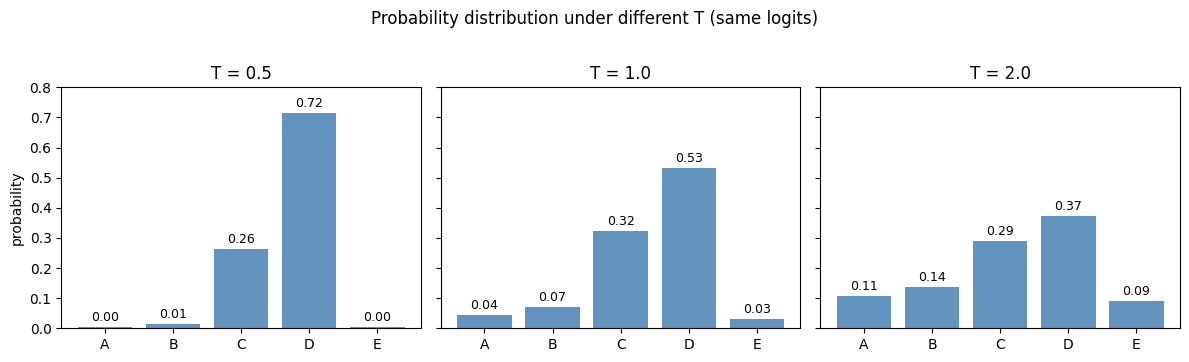

In [22]:
# 把上面那组 logits 在不同 T 下的概率分布画出来
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 模型对 5 个字符输出的原始 logits；D 是最可能的下一个字符
logits = torch.tensor([0.5, 1.0, 2.5, 3.0, 0.2])
labels = ['A', 'B', 'C', 'D', 'E']
print(f"原始 logits: {dict(zip(labels, logits.tolist()))}")
print()

# 三组 T 值对比同一组 logits
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for ax, T in zip(axes, [0.5, 1.0, 2.0]):
    probs = F.softmax(logits / T, dim=-1)
    ax.bar(labels, probs.tolist(), color='steelblue', alpha=0.85)
    ax.set_title(f"T = {T}")
    ax.set_ylim(0, 0.8)
    if ax is axes[0]:
        ax.set_ylabel("probability")
    # 柱顶标数字
    for i, p in enumerate(probs.tolist()):
        ax.text(i, p + 0.02, f"{p:.2f}", ha='center', fontsize=9)
plt.suptitle("Probability distribution under different T (same logits)", y=1.02)
plt.tight_layout()
plt.show()

print("观察：T=0.5 时 D 的概率被拉到 0.72，A/B/E 几乎为 0 → 模型很自信")
print("     T=2.0 时 5 个 token 概率都聚到 0.10~0.30 之间 → 模型很犹豫")
print()

# top_k 过滤演示
print("=== top_k 过滤（k=2）===")
v, top_idx = torch.topk(logits, 2)
kept = [labels[i] for i in top_idx.tolist()]
dropped = [labels[i] for i in range(5) if i not in top_idx.tolist()]
print(f"原始 logits: {dict(zip(labels, logits.tolist()))}")
print(f"保留前 2:    {kept} (logits {v.tolist()})")
print(f"丢弃:        {dropped}")
print()
print("采样只在 D 和 C 之间按概率抽，长尾里的 A/B/E 永远不会被选到。")
print("把 top_k 和 temperature 组合起来：")
print("  top_k=2 + T=0.5：D 几乎总是被选中（保留后归一化 D 占 ~0.62）")
print("  top_k=2 + T=2.0：D 和 C 接近五五开（差距被压平）")

In [23]:
import torch.nn.functional as F


@torch.no_grad()
def generate(model, prompt, max_new_tokens=200, temperature=0.8, top_k=None):
    """从 prompt 开始自回归生成文本

    temperature: 分布的尖锐程度，越小越确定
    top_k: 只在概率最高的 k 个 token 里采样；None 表示不做限制
    """
    model.eval()
    idx = torch.tensor([encode(prompt)], dtype=torch.long, device=device)

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -block_size:]
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :] / temperature

        if top_k is not None:
            # 只保留概率最高的 top_k 个 token，其余设为 -inf
            v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = float("-Inf")

        probs = torch.softmax(logits, dim=-1)
        idx_next = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, idx_next], dim=1)

    return decode(idx[0].tolist())


# 跟 train_gpt2.py 一样：从同一个 prompt 续写多次，看采样的多样性
print("=== 生成 1（prompt: 'ROMEO:'，top_k=10，temperature=0.8）===")
for i in range(3):
    print(f"--- sample {i+1} ---")
    print(generate(train_model, "ROMEO:", max_new_tokens=120, temperature=0.8, top_k=10))
    print()

print("=== 生成 2（prompt: 'To be, or'，temperature=0.5，无 top_k）===")
print(generate(train_model, "To be, or", max_new_tokens=120, temperature=0.5))

print("\n关键观察：模型只训了几百步，但已经能拼出像英文的单词和零散的句子结构。")
print("多训几千步，生成质量会接近真正的莎翁风格——这就是 nanoGPT 仓库里的 train_shakespeare_char 配置在做的事。")

=== 生成 1（prompt: 'ROMEO:'，top_k=10，temperature=0.8）===
--- sample 1 ---
ROMEO:
Fll and his thit the theared than so heer mes.

OLICESTUS:
MAnd that wisers ot havore elist, tup than an,
The it at ang

--- sample 2 ---
ROMEO:
Thig mofow, sthell angean the thas thant me mal,
An lof hen his then brurore tease wince me,
To she mee sthit mest hel 

--- sample 3 ---
ROMEO:
Thy deate he wlars o athof ind s hethis ther's bre thanesss tin ate blome,
Wed a whas me mie the ansong ane it ol of hi

=== 生成 2（prompt: 'To be, or'，temperature=0.5，无 top_k）===
To be, ore dof cooont the thee she of alls the ane a ame we beves ane:
The that or an on my for theate so ther mean mant ate o th

关键观察：模型只训了几百步，但已经能拼出像英文的单词和零散的句子结构。
多训几千步，生成质量会接近真正的莎翁风格——这就是 nanoGPT 仓库里的 train_shakespeare_char 配置在做的事。


**用选择题评测模型**

到目前为止，评测只有 val loss 一个数字。loss 下降说明模型在拟合训练分布，但"loss = 1.5"到底意味着模型"懂"了多少？这个数字本身没有直观含义。

一种更直白的评测办法是出选择题：给定一段上下文，让模型从几个候选续写里挑一个最像的。如果模型只会预测下一个字符，但预测得够准，它挑出来的就应该是真实下文；如果模型只是瞎猜，挑对正确答案的概率就是随机的。这种评测直接对应"模型有没有学到语言的连贯性"，比 loss 数字直观得多。

实现上，把上下文（context）和每个候选（candidate）拼起来送进模型，对每个候选计算模型在候选部分上的平均交叉熵——也就是模型认为这个候选有多"不像"接下来该出现的内容。loss 越小说明模型越相信这个候选。挑 loss 最小的那个。

有两个细节决定这套评测管不管用：

- **只算候选部分，不算 context**：context 对所有候选都一样，把它算进 loss 会让所有候选的分数都偏高同一个量，区分度变小。把 context 部分用 mask 屏蔽掉，只在候选部分累加 loss，4 个候选的差异才看得清楚。
- **用平均 loss 而不是总 loss**：候选长度可能不同，长的候选有更多 token 累加，天然 loss 偏大。改成平均每个 token 的 loss，长候选和短候选才能公平比较。

社区里最有名的这类评测是 HellaSwag，每个样本是一段描述加上 4 个续写选项（其中错误选项是人工精心构造的对抗样本，语法正确但物理上荒谬）。本节的实现思路同源，但换一种数据：在莎士比亚语料里现场构造选择题，跑在我们刚刚训练的字符级模型上。

**在 Shakespeare 语料上现场造题**

我们的模型是字符级的，词表只有 65 个字符，block_size 也只有 64，没法直接喂真 HellaSwag 样本（那些用 GPT-2 BPE 切，一个样本几百个 token）。但选择题的评测模式不依赖具体数据，可以自己造题：

从训练集里随机切一段长度 `context_len` 的文本作为上下文，紧跟着它的下一段就是"正确续写"。再从训练集其它随机位置切 3 段等长文本作为"干扰续写"。把这 4 段打乱顺序，让模型挑——挑出来的 loss 最低的那个，是不是正好是真实续写？

随机猜测的正确率是 25%（4 选 1）。模型如果学到了字符的局部统计规律，正确率应该高于这个基线。

In [24]:
import torch
import torch.nn.functional as F
import numpy as np

context_len = 32       # 上下文长度
completion_len = 16    # 候选长度
# 两者之和 48，留出余量给 block_size=64


def pick_best_candidate(model, context_ids, candidate_ids_list):
    """从候选列表里挑出模型最相信的那个，返回它在列表中的下标

    context_ids:        shape [context_len]  共享的上下文
    candidate_ids_list: list of 4 arrays, 每个形状 [completion_len]
    """
    # 拼成 [4, T]，T = context_len + completion_len
    rows = [np.concatenate([context_ids, c]).astype(np.int64) for c in candidate_ids_list]
    tokens = torch.tensor(np.stack(rows), dtype=torch.long, device=device)

    # mask: context 部分为 0（不算 loss），候选部分为 1
    single_mask = np.concatenate([np.zeros(context_len), np.ones(completion_len)]).astype(np.int64)
    mask = torch.tensor(np.stack([single_mask] * len(rows)), dtype=torch.long, device=device)

    # 注意：nanoGPT 在 targets=None 时只返回最后一个位置的 logits
    # 我们要每个位置的 logits，所以传 targets=tokens 让它输出完整 [b, T, vocab]
    logits, _ = model(tokens, targets=tokens)

    # 语言模型在每个位置 t 预测的是下一个 token
    # 所以错位对齐：用 logits[:-1] 预测 tokens[1:]
    pred_logits = logits[:, :-1, :]            # [4, T-1, vocab]
    target_tokens = tokens[:, 1:]              # [4, T-1]
    target_mask = mask[:, 1:]                  # [4, T-1]

    # 每个位置的 loss，reduction='none' 保留逐位置信息
    per_pos_loss = F.cross_entropy(
        pred_logits.reshape(-1, pred_logits.size(-1)),
        target_tokens.reshape(-1),
        reduction='none',
    ).view(tokens.size(0), -1)                 # [4, T-1]

    # 候选部分的平均 loss：屏蔽掉 context 位置的贡献
    avg_loss = (per_pos_loss * target_mask).sum(dim=1) / target_mask.sum(dim=1)
    return avg_loss.argmin().item()


@torch.no_grad()
def run_completion_quiz(model, n_examples=100):
    """在莎士比亚语料上跑 4 选 1 续写题，返回正确率"""
    model.eval()
    n_correct = 0

    for _ in range(n_examples):
        # 切一段上下文，紧接着的 completion_len 字符是"真实续写"
        start = np.random.randint(0, len(train_ids) - context_len - completion_len - 1)
        context = train_ids[start:start + context_len]
        true_completion = train_ids[start + context_len:start + context_len + completion_len]

        # 从其它位置切 3 段作为干扰项
        candidates = [true_completion]
        for _ in range(3):
            ws = np.random.randint(0, len(train_ids) - completion_len)
            candidates.append(train_ids[ws:ws + completion_len])

        # 打乱顺序，记住真实续写的位置
        order = np.random.permutation(4)
        shuffled = [candidates[i] for i in order]
        label = list(order).index(0)

        pred = pick_best_candidate(model, context, shuffled)
        n_correct += int(pred == label)

    model.train()
    return n_correct / n_examples


np.random.seed(42)
acc = run_completion_quiz(train_model, n_examples=100)
print(f"续写选择题正确率：{acc*100:.1f}%   (随机基线 25.0%)")
print()
print("关键观察：模型表面上只是在逐字符预测，但把候选部分的 loss 累加起来后，")
print("它能从 4 个候选里挑出与上下文最连贯的那一个——这就是选择题式评测的核心。")

续写选择题正确率：45.0%   (随机基线 25.0%)

关键观察：模型表面上只是在逐字符预测，但把候选部分的 loss 累加起来后，
它能从 4 个候选里挑出与上下文最连贯的那一个——这就是选择题式评测的核心。


## 小结

这一节所学的内容：

- GPT = Embedding + Position + 多层 Transformer Block + LayerNorm + 输出投影
- 中间 hidden state 的形状保持 `[batch, seq, d_model]`，只有最后一步变成 vocab_size
- logits 是每个位置对词表中所有 token 的打分，分数越高表示模型越倾向于预测该 token
- Weight tying 让 Token Embedding 和输出投影共享权重，GPT-2 由此节省约 3860 万参数；现代大模型（Qwen3、DeepSeek-V3 等）已改为独立权重
- 手写版和 nanoGPT 在结构上一致，工程差异包括可学习 position embedding、合并 Q/K/V 投影等
- special tokens 需要独立 ID，也需要相应扩容 Embedding 表
- nanoGPT 的完整训练流程：下载数据 → 切分 train/val → 构造 batch → forward/backward/optimizer 循环 → 验证 loss → 自回归生成
- 训练 loss 衡量模型在训练集上的拟合程度，验证 loss 衡量泛化能力，两者差距过大说明过拟合
- 生成时 temperature 越小分布越尖锐（更确定），越大越平（更随机）

下一节进入训练：loss 怎么算，模型怎么从随机初始化变成能生成有意义文本的状态。

## 作业

这道题检查对生成时 temperature 参数的理解。

> **关于 AI 辅助**：可以让 AI 解释 temperature 对概率分布的影响，但请自己写出缩放 logits 的那一行代码。

**作业 1：temperature 调整 logits**

现代 LLM 生成时经常用 temperature 控制随机性。temperature 越小，分布越尖锐（更确定）；越大，分布越平（更随机）。

**小提示**：常见写法是 `scaled_logits = logits / temperature`。

In [ ]:
# 作业 1：temperature 缩放 logits 填空
import torch

logits = torch.tensor([1.0, 2.0, 3.0])
temperature = 0.5

# TODO：用 temperature 缩放 logits
scaled_logits = """在这里缩放 logits"""

assert not isinstance(scaled_logits, str), "请先替换三引号里的占位内容"
assert torch.allclose(scaled_logits, torch.tensor([2.0, 4.0, 6.0])), scaled_logits
print("✅ 作业 1 通过：temperature < 1 会让 logits 差距变大，分布更尖锐")


**作业 2：Transformer Block 的参数量**MiniGPT 由 Embedding 层 + N 个 Transformer Block + 输出层组成。每个 Block 包含 Multi-Head Attention 和 FFN。假设 d = 64（hidden_size），1 层 Block。计算参数量（不含偏置）。小提示：MHA 参数 = 4 * d^2（Q/K/V/O），FFN 参数 = d * 4d + 4d * d = 8d^2。

In [25]:
# 作业 2：Transformer Block 参数量d = 64# TODO: MHA 参数量（Q, K, V, O 四个投影矩阵）mha_params = None  # 4 * d * d# TODO: FFN 参数量ffn_params = None  # d * 4d + 4d * d# TODO: Block 总参数量block_params = Noneassert mha_params is not Noneassert ffn_params is not Noneassert block_params is not Noneexpected_mha = 4 * d * dexpected_ffn = d * 4 * d + 4 * d * dexpected_block = expected_mha + expected_ffnassert mha_params == expected_mhaassert ffn_params == expected_ffnassert block_params == expected_blockprint(f'MHA 参数: {mha_params:,}')print(f'FFN 参数: {ffn_params:,}')print(f'Block 总计: {block_params:,}')print(f'MHA 占比: {mha_params/block_params:.1%}，FFN 占比: {ffn_params/block_params:.1%}')print('FFN 通常占 Block 参数量的 2/3。')print(chr(10004) + ' 作业 2 通过')

**作业 3：KV Cache 显存估算**自回归生成时，KV Cache 缓存每一步的 Key 和 Value 向量。假设 hidden_size = 768，num_heads = 12，num_layers = 12，seq_len = 1024，batch_size = 1，FP16。计算 KV Cache 的总显存占用。小提示：每层 KV Cache = 2 * batch * seq_len * num_heads * head_dim * 2 bytes。head_dim = hidden_size / num_heads。

In [26]:
# 作业 3：KV Cache 显存估算hidden_size = 768num_heads = 12num_layers = 12seq_len = 1024batch_size = 1bytes_per_element = 2head_dim = hidden_size // num_heads# TODO: 单层 KV Cache（bytes）per_layer_kv_bytes = None  # 2 * batch * seq_len * num_heads * head_dim * bytes# TODO: 所有层的总 KV Cache（GB）total_kv_gb = Noneassert per_layer_kv_bytes is not Nonetotal_kv_gb is not Noneexpected_per = 2 * batch_size * seq_len * num_heads * head_dim * bytes_per_elementexpected_total = expected_per * num_layers / 1e9assert per_layer_kv_bytes == expected_perassert abs(total_kv_gb - expected_total) < 0.01print(f'单层 KV Cache: {per_layer_kv_bytes / 1e6:.1f} MB')print(f'{num_layers} 层总 KV Cache: {total_kv_gb:.2f} GB')print('KV Cache 随序列长度线性增长，是长文本推理的主要显存瓶颈。')print(chr(10004) + ' 作业 3 通过')

## 参考资料

- Vaswani et al., [Attention Is All You Need](https://arxiv.org/abs/1706.03762), 2017 — Transformer 原始论文（Encoder-Decoder 架构），GPT 是其 Decoder-Only 变体
- Press & Wolf, [Using the Output Embedding to Improve Language Models](https://arxiv.org/abs/1608.05859), 2016 — Weight Tying 的原始论文，系统论证了输入与输出共享权重的动机
- Harvard NLP, [The Annotated Transformer](https://nlp.seas.harvard.edu/annotated-transformer/) — 原始 Encoder-Decoder Transformer 的逐行实现，可作为"完整对照"阅读：理解原始架构的 Encoder/Decoder/Cross-Attention，再对比本文的 Decoder-Only 设计
- Karpathy, [nanoGPT](https://github.com/karpathy/nanoGPT) — 本节对照的工程实现
- Radford et al., [Language Models are Unsupervised Multitask Learners](https://d4mucfpksywv.cloudfront.net/better-language-models/language-models.pdf), 2019 — GPT-2 论文